# Purpose
This notebook generates supplementary figures for the dual-adaptive algorithm (Fig S12-S18).

In [1]:
import pickle
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

import sys
sys.path.append("..")
from scripts import draw, intuition, basic_components as bcomp

In [2]:
cond_ls = ['A', 'C'] # Weight adjustment condition
eta = 10.0 # learning rate
K = 30 # number of instances

num_bins = 20 # number of bins on the logscale for the histogram of the upper tail of the weight distribution
dist_ls = ['Expon', 'InvNormal', 'Normal', 'Gamma', 'InvGamma', 'Lognorm', 'Weibull'] # candidate distributions
sig_thresh = 0.05 # significance level
k = 0 # the index of the representative network

# Networks generated at different $\tau_{reweight}$ and $p_{in} = 0.5$.

In [3]:
# Import resulted networks at the end of simulations
pin = 0.5
tau_ls = [0.05, 0.1, 0.5]
A_matrices = {}
for cond in cond_ls:
    A_matrices[cond] = {}
    for tau in tau_ls:
        f = open('./Output/dualAdapt/'+cond+'_pin_'+str(pin)+'_eta_'+str(eta)+'_tau_'+str(tau)+'_'+str(k)+'.pckl', 'rb')
        A_matrices[cond][tau], _ = pickle.load(f)
        f.close()

## Fig S12: Histogram of weight distributions and power-law fits of C-out condition

In [4]:
f = open('./Output/dualAdapt/PL_fit_pin_'+str(pin)+'.pckl', 'rb')
res_PL, PL_expon = pickle.load(f)
f.close()

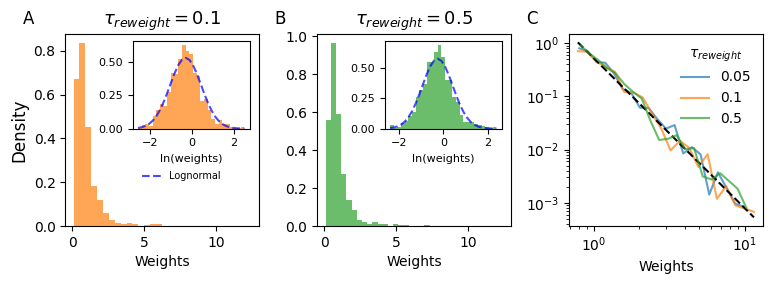

In [5]:
plt.rcParams["figure.figsize"] = (9, 2.5)
fig, ax1 = plt.subplots(1, 3)

cond = 'C'
# Histograms of the representative networks from the A-in condition
for l, tau in enumerate([0.1, 0.5]):
    weights = A_matrices[cond][tau][A_matrices[cond][tau]>0]
    ax1[l].hist(weights, bins=30, density=True,color = sns.color_palette(palette='tab10', n_colors=3)[l+1], alpha=0.7)
    ax1[l].set_xlabel('Weights',fontsize=10)
    ax1[l].set_title('$\\tau_{reweight} = $'+str(tau), fontsize = 13)
    ax1[l].tick_params(axis = 'both', labelsize=10)
    ax1[l].set_xlim([-0.5, 13])

    # histogram of log(weights)
    left, bottom, width, height = [0.2+l*0.28, 0.5, 0.13, 0.35]
    ax1_1 = fig.add_axes([left, bottom, width, height])
    x, mu, sig = draw.hist_log_weight(ax1_1, weights, num_bins = 30, color = sns.color_palette(palette='tab10', n_colors=3)[l+1])
    # the best fit distribution
    ylog = stats.norm.pdf(x, loc=mu, scale=sig)    
    ax1_1.plot(x, ylog, color='b', linestyle='dashed',alpha=0.7, label = 'Lognormal')
    if l == 0:
        ax1_1.legend(fontsize = 7, bbox_to_anchor=[0, -0.7], loc='lower left', frameon=False)
ax1[0].set_ylabel('Density',fontsize=12)

# Draw power-law fits of the representative networks
for l, tau in enumerate([0.05, 0.1, 0.5]): 
    weights = A_matrices[cond][tau][A_matrices[cond][tau]>0]
    res = res_PL[cond][tau].iloc[k]
    draw_fit = False
    if tau == 0.1:
        draw_fit = True
    draw.draw_power_law(ax1[2], weights, res, tau, num_bins, color = sns.color_palette(palette='tab10', n_colors=5)[l], draw_fit=draw_fit)
ax1[2].set_xscale('log')
ax1[2].set_yscale('log')
ax1[2].legend(title = '$\\tau_{reweight}$', frameon=False)
ax1[2].set_xlabel('Weights',fontsize=10)

ax1[0].text(-0.22, 1.05, 'A', transform=ax1[0].transAxes, size=12)
ax1[1].text(-0.22, 1.05, 'B', transform=ax1[1].transAxes, size=12)
ax1[2].text(-0.22, 1.05, 'C', transform=ax1[2].transAxes, size=12)

fig.subplots_adjust(wspace = 0.3)
#plt.savefig('../fig/Fig S12.svg', dpi = 300)

## Fig S13: Model comparison

In [6]:
f = open('./Output/dualAdapt/KS_stats_pin_'+str(pin)+'.pckl', 'rb')
KS_stats, wilcoxon_p = pickle.load(f)
f.close()

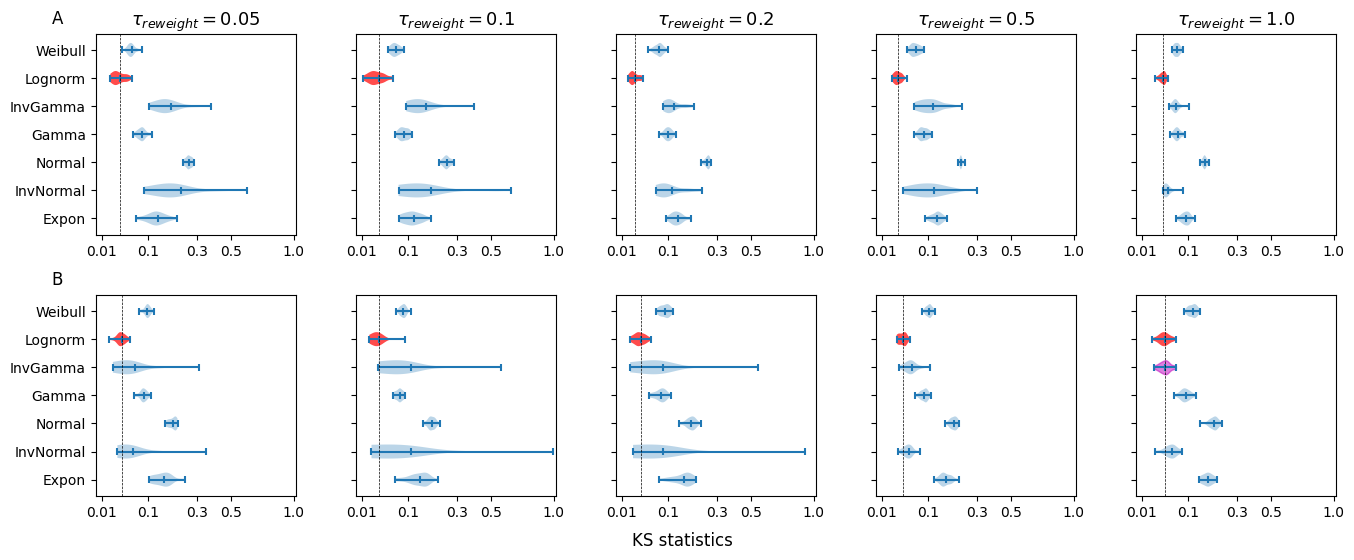

In [7]:
plt.rcParams["figure.figsize"] = (16, 6)
fig, ax1 = plt.subplots(2, 5)

for s, cond in enumerate(cond_ls):
    # Plot the KS statistics
    for i, tau in enumerate([0.05, 0.1, 0.2, 0.5, 1.0]):
        draw.draw_KS_stats(ax1[s, i], KS_stats[cond][tau], wilcoxon_p[cond][tau], sig_thresh, xmin=0.005, xmax=1.02)
        ax1[s, i].set_xticks([0.01, 0.1, 0.3, 0.5, 1.0], labels= [0.01, 0.1, 0.3, 0.5, 1.0])
        if s == 0:
            ax1[s, i].set_title('$\\tau_{reweight} = $'+str(tau), fontsize = 13)
    ax1[s, 0].set_yticks([l + 1 for l, dist in enumerate(dist_ls)], labels= dist_ls)

ax1[0, 0].text(-0.22, 1.05, 'A', transform=ax1[0, 0].transAxes, size=12)
ax1[1, 0].text(-0.22, 1.05, 'B', transform=ax1[1, 0].transAxes, size=12)
ax1[1, 2].text(0.08, -0.25, 'KS statistics', transform=ax1[1, 2].transAxes, size=12)

fig.subplots_adjust(wspace = 0.3, hspace = 0.3)
#plt.savefig('../fig/Fig S13.svg', dpi = 300)

## Fig S14: Stationary analysis

In [8]:
f = open('./Output_long/dualAdapt/summary_stats_evol_pin_'+str(pin)+'.pckl', 'rb')
std, skew, kurt = pickle.load(f)
f.close()

f = open('./Output_long/dualAdapt/Topo_metrics_evol_pin_'+str(pin)+'.pckl', 'rb')
cc, ae, mod = pickle.load(f)
f.close()

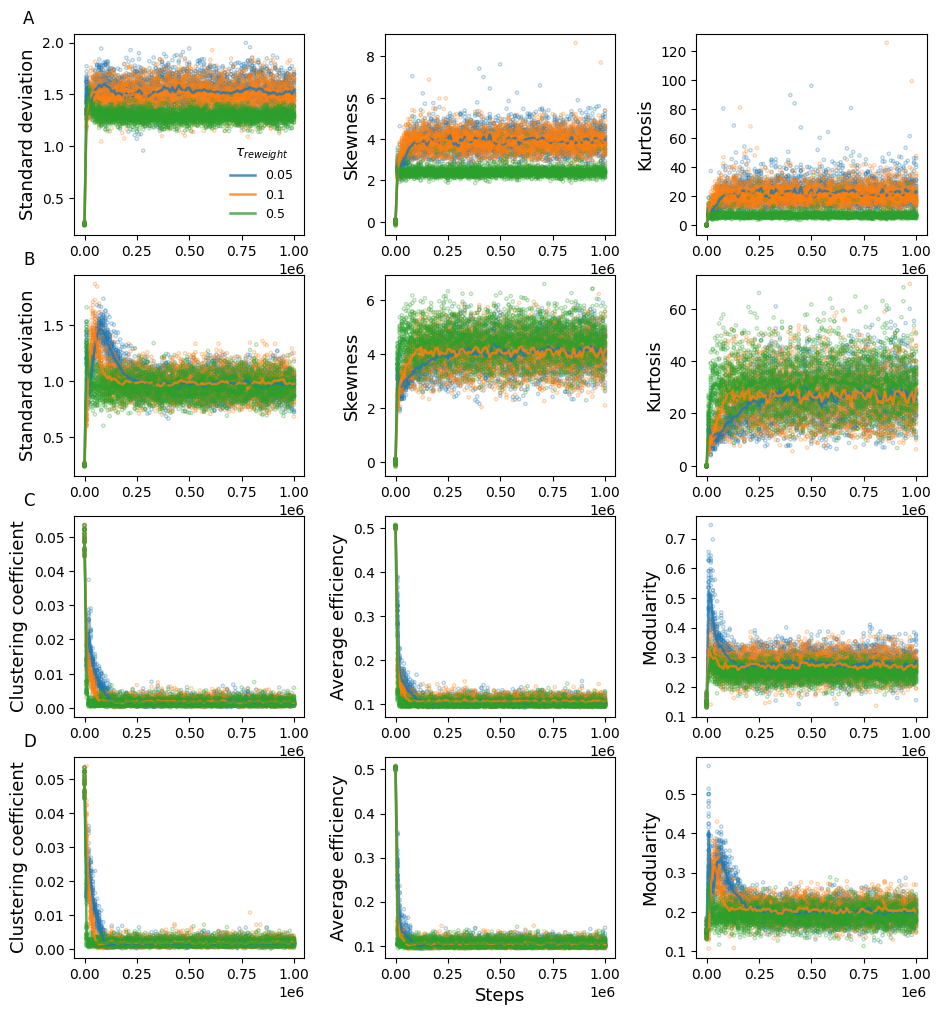

In [9]:
tau_ls = [0.05, 0.1, 0.5]
plt.rcParams["figure.figsize"] = (11, 12)
fig, ax1 = plt.subplots(4, 3)
for l, cond in enumerate(cond_ls):
    for s, tau in enumerate(tau_ls):
        draw.draw_mean_scatter(ax1[l, 0], list(std[cond][tau].keys()), std[cond][tau], color = sns.color_palette(palette='tab10', n_colors=3)[s], 
                               label=str(tau), shift = 0, jitter = 1)
        draw.draw_mean_scatter(ax1[l, 1], list(skew[cond][tau].keys()), skew[cond][tau], color = sns.color_palette(palette='tab10', n_colors=3)[s], 
                               label=str(tau), shift = 0, jitter = 1)
        draw.draw_mean_scatter(ax1[l, 2], list(kurt[cond][tau].keys()), kurt[cond][tau], color = sns.color_palette(palette='tab10', n_colors=3)[s], 
                               label=str(tau), shift = 0, jitter = 1)
        draw.draw_mean_scatter(ax1[l+2, 0], list(cc[cond][tau].keys()), cc[cond][tau], color = sns.color_palette(palette='tab10', n_colors=3)[s], 
                               label=str(tau), shift = 0, jitter = 1)
        draw.draw_mean_scatter(ax1[l+2, 1], list(ae[cond][tau].keys()), ae[cond][tau], color = sns.color_palette(palette='tab10', n_colors=3)[s], 
                               label=str(tau), shift = 0, jitter = 1)
        draw.draw_mean_scatter(ax1[l+2, 2], list(mod[cond][tau].keys()), mod[cond][tau], color = sns.color_palette(palette='tab10', n_colors=3)[s], 
                               label=str(tau), shift = 0, jitter = 1)
        
    ax1[l, 0].set_ylabel('Standard deviation', fontsize = 13)
    ax1[l, 1].set_ylabel('Skewness', fontsize = 13)
    ax1[l, 2].set_ylabel('Kurtosis', fontsize = 13)
    ax1[l+2, 0].set_ylabel('Clustering coefficient', fontsize = 13)
    ax1[l+2, 1].set_ylabel('Average efficiency', fontsize = 13)
    ax1[l+2, 2].set_ylabel('Modularity', fontsize = 13)

ax1[0, 0].legend(title = '$\\tau_{reweight}$', fontsize=9, frameon=False, bbox_to_anchor=(0.5, 0., 0.5, 0.5))
ax1[3, 1].set_xlabel('Steps', fontsize = 13)

ax1[0, 0].text(-0.22, 1.05, 'A', transform=ax1[0, 0].transAxes, size=12)
ax1[1, 0].text(-0.22, 1.05, 'B', transform=ax1[1, 0].transAxes, size=12)
ax1[2, 0].text(-0.22, 1.05, 'C', transform=ax1[2, 0].transAxes, size=12)
ax1[3, 0].text(-0.22, 1.05, 'D', transform=ax1[3, 0].transAxes, size=12)

fig.subplots_adjust(wspace = 0.35, hspace = 0.2)
#plt.savefig('../fig/Fig S14.svg', dpi = 300)

# Intuitive explanation

## Fig S15: weight increments are approximately proportional to connection weight for wider range of $\tau_{reweight}$ in a rewired network.

In [10]:
f = open('./Output/Rewire_alone_FigS15.pckl', 'rb') 
rewired = pickle.load(f)
f.close()

In [11]:
A0 = rewired[500000].copy() # a rewired network with fixed weights
w = A0[A0>0] # weights of this network, following a normal distribution

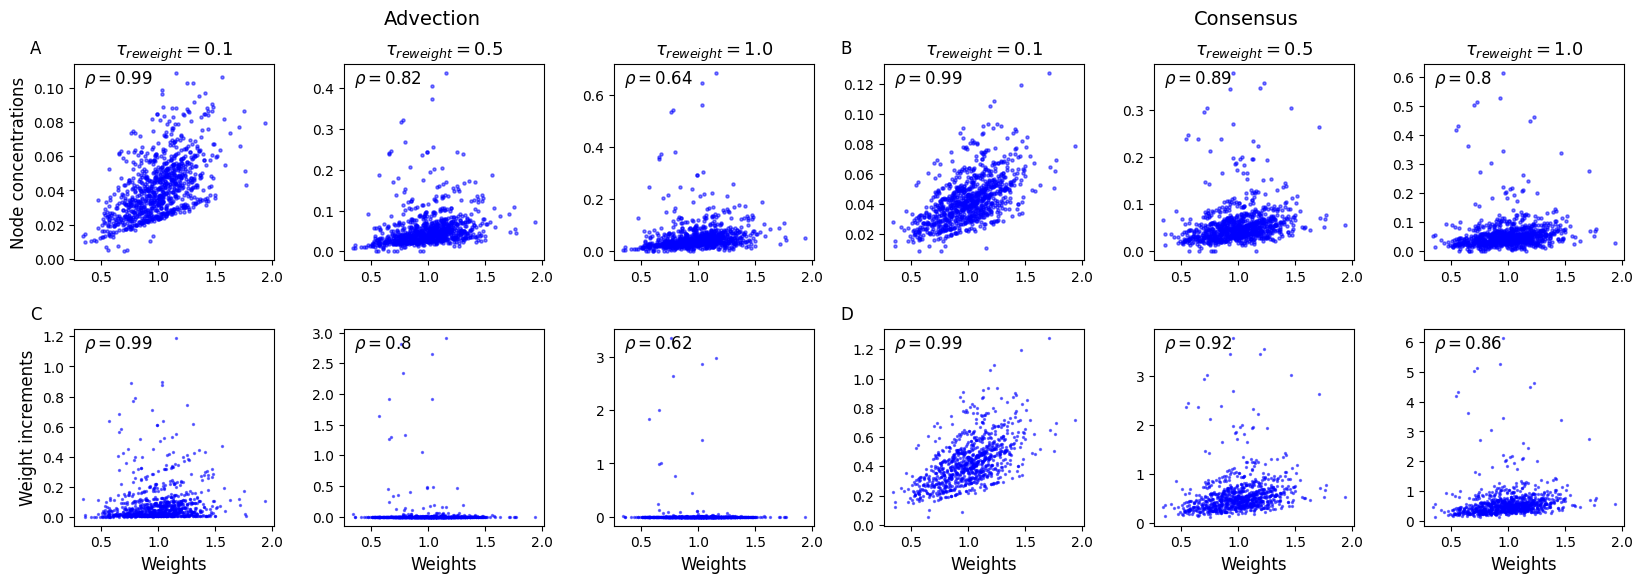

In [12]:
plt.rcParams["figure.figsize"] = (20, 6)
fig, ax1 = plt.subplots(2, 6)

for m, tau in enumerate([0.1, 0.5, 1.0]):
    # relation between node states and connection weights
    adv_kernel = bcomp.advection_kernel(A0, tau)
    weight_ls, kernel_ls, rho = intuition.kernel_weight_relation(A0, adv_kernel, flag = 'Advection')
    ax1[0, m].scatter(weight_ls, kernel_ls, s = 5, c='b', alpha = 0.5)
    ax1[0, m].text(0.05, 0.9, '$\\rho=$'+str(np.round(rho, 2)), transform=ax1[0, m].transAxes, size=12)
    ax1[0, m].set_title('$\\tau_{reweight} = $'+str(tau), fontsize = 13)
    
    con_kernel = bcomp.consensus_kernel(A0, tau)
    weight_ls, kernel_ls, rho = intuition.kernel_weight_relation(A0, con_kernel, flag = 'Consensus')
    ax1[0, m+3].scatter(weight_ls, kernel_ls, s = 5, c='b', alpha = 0.5)
    ax1[0, m+3].text(0.05, 0.9, '$\\rho=$'+str(np.round(rho, 2)), transform=ax1[0, m+3].transAxes, size=12)
    ax1[0, m+3].set_title('$\\tau_{reweight} = $'+str(tau), fontsize = 13)

    # relation between weight increments and connection weights
    weight_ls, weight_increment_ls, rho = intuition.increment_weight_relation(A0, adv_kernel, eta, flag = 'Advection')
    ax1[1, m].scatter(weight_ls, weight_increment_ls, s=2, c='b', alpha = 0.5)
    ax1[1, m].text(0.05, 0.9, '$\\rho=$'+str(np.round(rho, 2)), transform=ax1[1, m].transAxes, size=12)
    ax1[1, m].set_xlabel('Weights', fontsize = 12)

    weight_ls, weight_increment_ls, rho = intuition.increment_weight_relation(A0, con_kernel, eta, flag = 'Consensus')
    ax1[1, m+3].scatter(weight_ls, weight_increment_ls, s=2, c='b', alpha = 0.5)
    ax1[1, m+3].text(0.05, 0.9, '$\\rho=$'+str(np.round(rho, 2)), transform=ax1[1, m+3].transAxes, size=12)
    ax1[1, m+3].set_xlabel('Weights', fontsize = 12)

ax1[0, 0].set_ylabel('Node concentrations', fontsize = 12)
ax1[1, 0].set_ylabel('Weight increments', fontsize = 12)
ax1[0, 1].text(0.2, 1.2, 'Advection', transform=ax1[0, 1].transAxes, size=14)
ax1[0, 4].text(0.2, 1.2, 'Consensus', transform=ax1[0, 4].transAxes, size=14)
ax1[0, 0].text(-0.22, 1.05, 'A', transform=ax1[0, 0].transAxes, size=12)
ax1[0, 3].text(-0.22, 1.05, 'B', transform=ax1[0, 3].transAxes, size=12)
ax1[1, 0].text(-0.22, 1.05, 'C', transform=ax1[1, 0].transAxes, size=12)
ax1[1, 3].text(-0.22, 1.05, 'D', transform=ax1[1, 3].transAxes, size=12)
plt.subplots_adjust(wspace = 0.35, hspace = 0.35)
#plt.savefig('../fig/Fig S15.svg', dpi = 300)

# Networks generated at different $p_{in}$.

In [13]:
# Import resulted networks at the end of simulations
tau_ls = [0.05, 0.1, 0.5]
pin_ls = [0.3, 0.5, 0.7]
A_matrices = {}
for cond in cond_ls:
    A_matrices[cond] = {}
    for tau in tau_ls:
        A_matrices[cond][tau] = {}
        for pin in pin_ls:
            f = open('./Output/dualAdapt/'+cond+'_pin_'+str(pin)+'_eta_'+str(eta)+'_tau_'+str(tau)+'_'+str(k)+'.pckl', 'rb')
            A_matrices[cond][tau][pin], _ = pickle.load(f)
            f.close()

## Fig S16: Model comparison at $\tau_{reweight}=0.1$ across various $p_{in}$

In [14]:
tau = 0.1
f = open('./Output/dualAdapt/KS_stats_tau_'+str(tau)+'.pckl', 'rb')
KS_stats, wilcoxon_p = pickle.load(f)
f.close()

pin = 0.9
f = open('./Output/dualAdapt/weibull_fit_pin_'+str(pin)+'_tau_'+str(tau)+'_A.pckl', 'rb')
wb_params = pickle.load(f)
f.close()

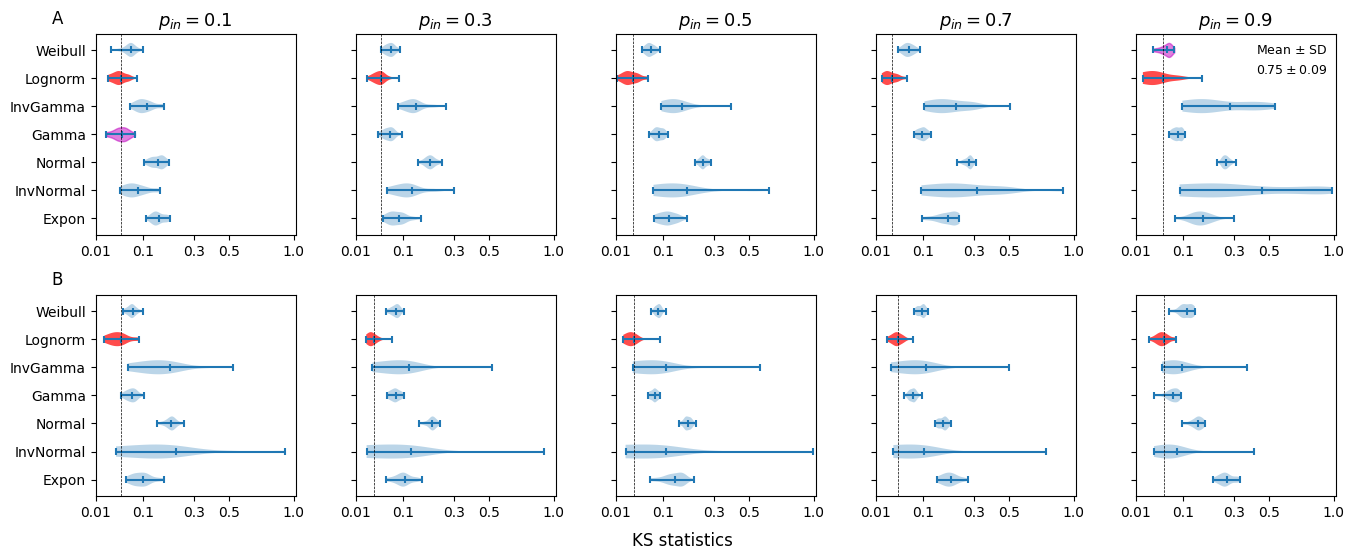

In [15]:
plt.rcParams["figure.figsize"] = (16, 6)
fig, ax1 = plt.subplots(2, 5)

for s, cond in enumerate(cond_ls):
    # Plot the KS statistics
    for i, pin in enumerate([0.1, 0.3, 0.5, 0.7, 0.9]):
        draw.draw_KS_stats(ax1[s, i], KS_stats[cond][pin], wilcoxon_p[cond][pin], sig_thresh, xmin=0.01, xmax=1.02)
        ax1[s, i].set_xticks([0.01, 0.1, 0.3, 0.5, 1.0], labels= [0.01, 0.1, 0.3, 0.5, 1.0])
        if s == 0:
            ax1[s, i].set_title('$p_{in} = $'+str(pin), fontsize = 13)
    ax1[s, 0].set_yticks([l + 1 for l, dist in enumerate(dist_ls)], labels= dist_ls)

# Add the estimated parameters of Weibull fit at pin=0.9 of A-in condition
ax1[0, 4].text(0.6, 0.9, 'Mean $\\pm$ SD', transform=ax1[0, 4].transAxes, fontsize=9)
ax1[0, 4].text(0.6, 0.8, fr"${wb_params['loc']:.2f} \pm {wb_params['scale']:.2f}$", transform=ax1[0, 4].transAxes, fontsize=9)

ax1[0, 0].text(-0.22, 1.05, 'A', transform=ax1[0, 0].transAxes, size=12)
ax1[1, 0].text(-0.22, 1.05, 'B', transform=ax1[1, 0].transAxes, size=12)
ax1[1, 2].text(0.08, -0.25, 'KS statistics', transform=ax1[1, 2].transAxes, size=12)

fig.subplots_adjust(wspace = 0.3, hspace = 0.3)
#plt.savefig('../fig/Fig S16.svg', dpi = 300)

## Fig S17: Histogram of weight distribution at $\tau_{reweight}=0.1$ across various $p_{in}$

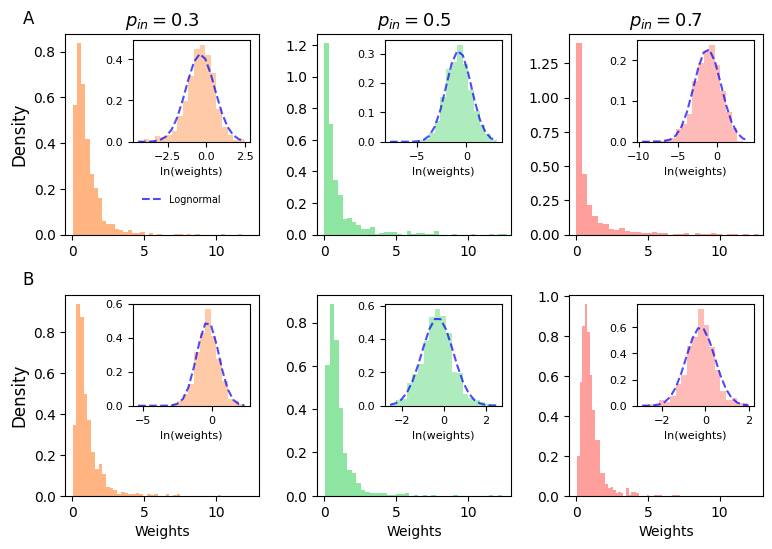

In [16]:
plt.rcParams["figure.figsize"] = (9, 6)
fig, ax1 = plt.subplots(2, 3)

k = 0
tau = 0.1
for s, cond in enumerate(cond_ls):
    for l, pin in enumerate([0.3, 0.5, 0.7]):
        # Histograms of the representative networks
        weights = A_matrices[cond][tau][pin][A_matrices[cond][tau][pin]>0]
        ax1[s, l].hist(weights, bins = 40, density = True, color = sns.color_palette(palette='pastel', n_colors=5)[l+1])
        ax1[s, l].tick_params(axis = 'both', labelsize=10)
        ax1[s, l].set_xlim([-0.5, 13])
        if s == 0:
            ax1[s, l].set_title('$p_{in} = $'+str(pin), fontsize = 13)
        if s == 1:
            ax1[s, l].set_xlabel('Weights',fontsize=10)
        
        left, bottom, width, height = [0.2+l*0.28, 0.7-0.44*s, 0.13, 0.17]
        ax1_1 = fig.add_axes([left, bottom, width, height])
        # histogram of log(weights)
        x, mu, sig = draw.hist_log_weight(ax1_1, weights, num_bins = 20, color = sns.color_palette(palette='pastel', n_colors=5)[l+1])
        # the best fit distribution
        ylog = stats.norm.pdf(x, loc=mu, scale=sig)    
        ax1_1.plot(x, ylog, color='b', linestyle='dashed',alpha=0.7, label = 'Lognormal')
        if (l == 0)&(s==0):
            ax1_1.legend(fontsize = 7, frameon=False, bbox_to_anchor=[0, -0.7], loc='lower left')
    ax1[s, 0].set_ylabel('Density',fontsize=12)

ax1[0, 0].text(-0.22, 1.05, 'A', transform=ax1[0, 0].transAxes, size=12)
ax1[1, 0].text(-0.22, 1.05, 'B', transform=ax1[1, 0].transAxes, size=12)
fig.subplots_adjust(wspace = 0.3, hspace = 0.3)
#plt.savefig('../fig/Fig S17.svg', dpi = 300)

## Fig S18: Stationary analysis

In [17]:
f = open('./Output_long/dualAdapt/summary_stats_evol_tau_'+str(tau)+'.pckl', 'rb')
std, skew, kurt = pickle.load(f)
f.close()

f = open('./Output_long/dualAdapt/Topo_metrics_evol_tau_'+str(tau)+'.pckl', 'rb')
cc, ae, mod = pickle.load(f)
f.close()

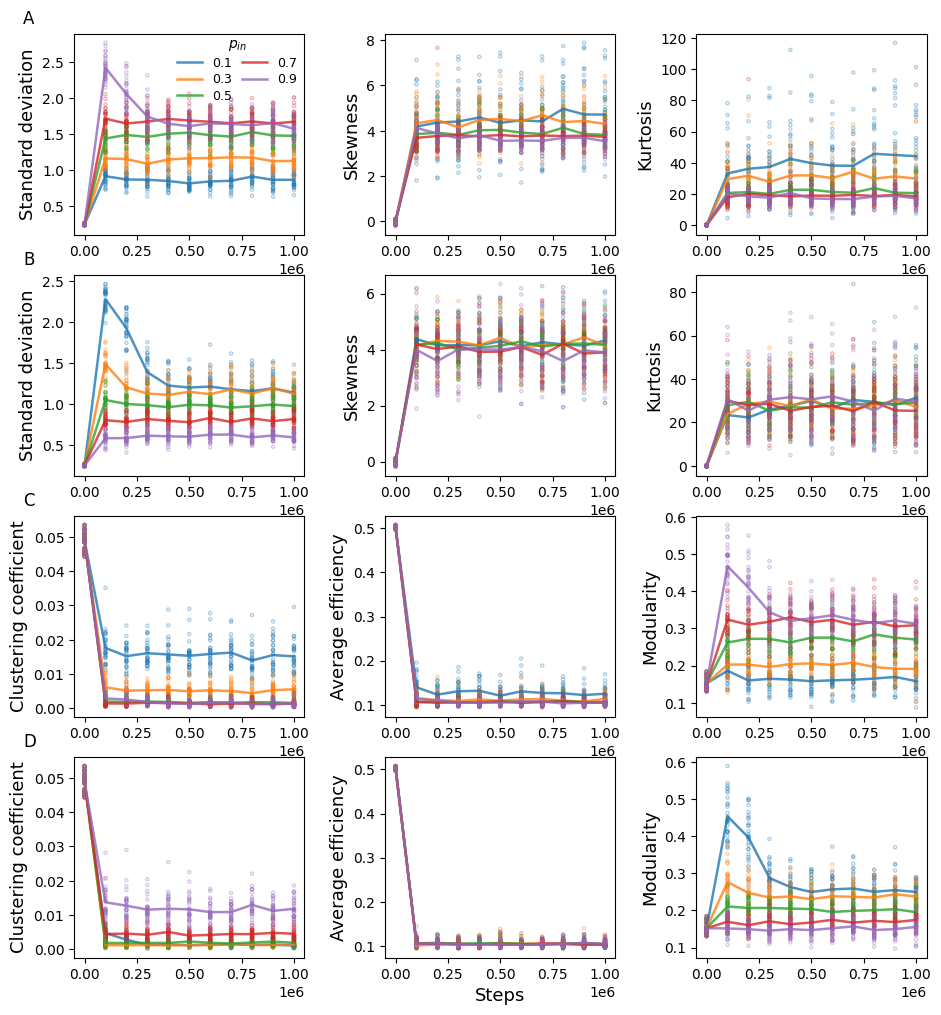

In [18]:
pin_ls = [0.1, 0.3, 0.5, 0.7, 0.9]

plt.rcParams["figure.figsize"] = (11, 12)
fig, ax1 = plt.subplots(4, 3)
for l, cond in enumerate(cond_ls):
    for s, pin in enumerate(pin_ls):
        draw.draw_mean_scatter(ax1[l, 0], list(std[cond][pin].keys()), std[cond][pin], color = sns.color_palette(palette='tab10', n_colors=6)[s], 
                               label=str(pin), shift = 0, jitter = 1)
        draw.draw_mean_scatter(ax1[l, 1], list(skew[cond][pin].keys()), skew[cond][pin], color = sns.color_palette(palette='tab10', n_colors=6)[s], 
                               label=str(pin), shift = 0, jitter = 1)
        draw.draw_mean_scatter(ax1[l, 2], list(kurt[cond][pin].keys()), kurt[cond][pin], color = sns.color_palette(palette='tab10', n_colors=6)[s], 
                               label=str(pin), shift = 0, jitter = 1)
        draw.draw_mean_scatter(ax1[l+2, 0], list(cc[cond][pin].keys()), cc[cond][pin], color = sns.color_palette(palette='tab10', n_colors=6)[s], 
                               label=str(pin), shift = 0, jitter = 1)
        draw.draw_mean_scatter(ax1[l+2, 1], list(ae[cond][pin].keys()), ae[cond][pin], color = sns.color_palette(palette='tab10', n_colors=6)[s], 
                               label=str(pin), shift = 0, jitter = 1)
        draw.draw_mean_scatter(ax1[l+2, 2], list(mod[cond][pin].keys()), mod[cond][pin], color = sns.color_palette(palette='tab10', n_colors=6)[s], 
                               label=str(pin), shift = 0, jitter = 1)
        
    ax1[l, 0].set_ylabel('Standard deviation', fontsize = 13)
    ax1[l, 1].set_ylabel('Skewness', fontsize = 13)
    ax1[l, 2].set_ylabel('Kurtosis', fontsize = 13)
    ax1[l+2, 0].set_ylabel('Clustering coefficient', fontsize = 13)
    ax1[l+2, 1].set_ylabel('Average efficiency', fontsize = 13)
    ax1[l+2, 2].set_ylabel('Modularity', fontsize = 13)
ax1[0, 0].legend(title = '$p_{in}$', fontsize=9, frameon=False, ncol = 2, bbox_to_anchor=(0.4, 0.6, 0.4, 0.4), columnspacing=0.8, labelspacing = 0.3)
ax1[3, 1].set_xlabel('Steps', fontsize = 13)

ax1[0, 0].text(-0.22, 1.05, 'A', transform=ax1[0, 0].transAxes, size=12)
ax1[1, 0].text(-0.22, 1.05, 'B', transform=ax1[1, 0].transAxes, size=12)
ax1[2, 0].text(-0.22, 1.05, 'C', transform=ax1[2, 0].transAxes, size=12)
ax1[3, 0].text(-0.22, 1.05, 'D', transform=ax1[3, 0].transAxes, size=12)

fig.subplots_adjust(wspace = 0.35, hspace = 0.2)
#plt.savefig('../fig/Fig S18.svg', dpi = 300)